# DATA 266 Lab 1 - Task 3: CycleGAN Image Style Transfer

**Student:** Omkar Rajale  
**SID4:** 0298  
**SEED:** 298  
**SLICE:** 298  
**HP_ID:** 4  
**CLS_A:** 8  
**CLS_B:** 1

This notebook trains a CycleGAN using two unpaired image folders:

- Domain A: `monet_jpg` (Monet-style paintings)
- Domain B: `photo_jpg` (real photographs)

The model learns both directions:

- Monet to Photo: `G_A2B`
- Photo to Monet: `G_B2A`

**Run 3 (DiffAugment + generator EMA).** Run 1 (baseline, ConvTranspose) scored FID 103.04 and Run 2 (bilinear upsampling) scored FID 112.78, so Run 3 goes back to the Run 1 generator and adds DiffAugment on the discriminator inputs, an exponential moving average (EMA) of the generator weights, and a longer schedule.

Run the notebook once with `RUN_MODE = "smoke"`. If every cell works, change it to `RUN_MODE = "full"` and train the final model.

## 1. Install the required packages

Run this cell once after starting the Colab runtime. The evaluation packages are used only to measure saved results. They are not used to train the CycleGAN or create Kaggle images.

In [1]:
from datetime import datetime

print(datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

2026-09-30 00:40:18


In [2]:
%pip install -q kaggle lpips scipy pandas matplotlib pillow tqdm scikit-learn tabulate

Note: you may need to restart the kernel to use updated packages.


## 2. Imports, seed, and output logging

`RUN_LOG.txt` receives the normal printed console output with timestamps. Rich notebook outputs such as images are still saved separately in the `outputs` folder.

In [3]:
import os
import sys
import csv
import json
import math
import time
import random
import copy
import shutil
import zipfile
import subprocess
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import linalg
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import inception_v3, Inception_V3_Weights
from torchvision.utils import make_grid

SEED = 298

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

print("Seed:", SEED)
print("PyTorch version:", torch.__version__)

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Seed: 298
PyTorch version: 2.1.2


In [4]:
# This class sends printed output to both the notebook and RUN_LOG.txt.
class TeeLogger:
    def __init__(self, terminal, log_path):
        self.terminal = terminal
        self.log_file = open(log_path, "a", buffering=1)

    def write(self, message):
        self.terminal.write(message)
        if message.strip():
            timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            self.log_file.write(f"[{timestamp}] {message}")

    def flush(self):
        self.terminal.flush()
        self.log_file.flush()

    def isatty(self):
        return False


# Start with a local folder. The next cell can move it to Google Drive.
LOCAL_PROJECT_DIR = Path("/content/task3_cyclegan_run3_diffaug_ema") if Path("/content").exists() else Path.cwd() / "task3_cyclegan_run3_diffaug_ema"
LOCAL_PROJECT_DIR.mkdir(parents=True, exist_ok=True)

RUN_LOG_PATH = LOCAL_PROJECT_DIR / "RUN_LOG.txt"

if not isinstance(sys.stdout, TeeLogger):
    sys.stdout = TeeLogger(sys.stdout, RUN_LOG_PATH)
    sys.stderr = TeeLogger(sys.stderr, RUN_LOG_PATH)

print("Logging started")
print("Initial project folder:", LOCAL_PROJECT_DIR)

Logging started
Initial project folder: /app/task3_cyclegan_run3_diffaug_ema
Normal printing is working again.


In [5]:
import sys

# Restore normal notebook output.
while hasattr(sys.stdout, "terminal"):
    old_stdout = sys.stdout
    sys.stdout = old_stdout.terminal

    try:
        old_stdout.log_file.close()
    except Exception:
        pass

while hasattr(sys.stderr, "terminal"):
    old_stderr = sys.stderr
    sys.stderr = old_stderr.terminal

    try:
        old_stderr.log_file.close()
    except Exception:
        pass

print("Normal printing is working again.")

## 3. Colab and project configuration

For Colab, Google Drive is recommended because the runtime can disconnect. Set `USE_GOOGLE_DRIVE = False` only when running locally on the RTX 4090/5090.

The personal-parameter page says HP parameters should be used only when the assignment explicitly maps them. Task 3 does not provide an HP mapping, so `HP_ID = 4` is reported but does not change the CycleGAN settings.

In [6]:
from pathlib import Path

# Current Jupyter working folder
WORK_DIR = Path.cwd()

# Run 1 folder contains the dataset
RUN1_PROJECT_DIR = WORK_DIR / "task3_cyclegan"

# Run 3 will save its checkpoints and results in a new folder
PROJECT_DIR = WORK_DIR / "task3_cyclegan_run3_diffaug_ema"


# ---------------------------------------------------------
# Dataset folders
# Reuse the dataset from Run 1
# ---------------------------------------------------------
DATASET_ROOT = RUN1_PROJECT_DIR / "dataset"

MONET_DIR = DATASET_ROOT / "monet_jpg"
PHOTO_DIR = DATASET_ROOT / "photo_jpg"


# ---------------------------------------------------------
# Run 3 output folders
# ---------------------------------------------------------
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"

PRED_A2B_DIR = OUTPUT_DIR / "pred_A2B_monet_to_photo"
PRED_B2A_DIR = OUTPUT_DIR / "pred_B2A_photo_to_monet"
KAGGLE_IMAGE_DIR = OUTPUT_DIR / "kaggle_photo_to_monet"
AUDIT_DIR = OUTPUT_DIR / "human_audit"


# Create the new Run 3 folders
for folder in [
    CHECKPOINT_DIR,
    FIGURE_DIR,
    PRED_A2B_DIR,
    PRED_B2A_DIR,
    KAGGLE_IMAGE_DIR,
    AUDIT_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)


# Run 3 log file
FINAL_RUN_LOG_PATH = PROJECT_DIR / "RUN_LOG.txt"


# Display the selected paths
print("Current working directory:", WORK_DIR)
print("Run 1 folder:", RUN1_PROJECT_DIR)
print("Run 3 project folder:", PROJECT_DIR)
print("Dataset folder:", DATASET_ROOT)
print("Monet folder exists:", MONET_DIR.exists())
print("Photo folder exists:", PHOTO_DIR.exists())

Current working directory: /app
Run 1 folder: /app/task3_cyclegan
Run 3 project folder: /app/task3_cyclegan_run3_diffaug_ema
Dataset folder: /app/task3_cyclegan/dataset
Monet folder exists: True
Photo folder exists: True


## 4. Optional: download the private Kaggle competition data

Skip this section if `monet_jpg` and `photo_jpg` are already inside `DATASET_ROOT`.

Before running:

1. Join the private class competition in your browser.
2. Open the competition page and copy the text after `/competitions/` from its URL.
3. Paste that text into `COMPETITION_SLUG`.
4. Upload your `kaggle.json` when prompted.

Never commit `kaggle.json` to GitHub.

In [7]:
DOWNLOAD_FROM_KAGGLE = False
COMPETITION_SLUG = "PASTE_PRIVATE_COMPETITION_SLUG_HERE"

if DOWNLOAD_FROM_KAGGLE:
    if COMPETITION_SLUG.startswith("PASTE_"):
        raise ValueError("Paste the Kaggle competition slug first.")

    from google.colab import files

    print("Upload kaggle.json")
    uploaded = files.upload()

    if "kaggle.json" not in uploaded:
        raise FileNotFoundError("kaggle.json was not uploaded.")

    kaggle_folder = Path.home() / ".kaggle"
    kaggle_folder.mkdir(exist_ok=True)
    kaggle_file = kaggle_folder / "kaggle.json"
    kaggle_file.write_bytes(uploaded["kaggle.json"])
    os.chmod(kaggle_file, 0o600)

    zip_path = PROJECT_DIR / "competition_data.zip"

    subprocess.run(
        ["kaggle", "competitions", "download", "-c", COMPETITION_SLUG, "-p", str(PROJECT_DIR)],
        check=True,
    )

    downloaded_zips = sorted(PROJECT_DIR.glob("*.zip"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not downloaded_zips:
        raise FileNotFoundError("Kaggle did not download a ZIP file.")

    with zipfile.ZipFile(downloaded_zips[0], "r") as zip_file:
        zip_file.extractall(DATASET_ROOT)

    kaggle_file.unlink(missing_ok=True)
    print("Dataset extracted to:", DATASET_ROOT)
else:
    print("Kaggle download skipped.")

Kaggle download skipped.


## 5. Find and inspect the two dataset folders

The code searches below `DATASET_ROOT`, so one extra folder created during ZIP extraction is okay.

In [8]:
def find_folder(root, folder_name):
    matches = list(Path(root).rglob(folder_name))
    matches = [path for path in matches if path.is_dir()]
    if not matches:
        raise FileNotFoundError(f"Could not find '{folder_name}' below {root}")
    return matches[0]


MONET_DIR = find_folder(DATASET_ROOT, "monet_jpg")
PHOTO_DIR = find_folder(DATASET_ROOT, "photo_jpg")


def get_image_paths(folder):
    paths = []
    for pattern in ["*.jpg", "*.jpeg", "*.JPG", "*.JPEG"]:
        paths.extend(folder.glob(pattern))
    return sorted(set(paths))


monet_paths = get_image_paths(MONET_DIR)
photo_paths = get_image_paths(PHOTO_DIR)

if len(monet_paths) == 0 or len(photo_paths) == 0:
    raise ValueError("One of the image folders is empty.")

print("Monet folder:", MONET_DIR)
print("Photo folder:", PHOTO_DIR)
print("Number of Monet images:", len(monet_paths))
print("Number of photo images:", len(photo_paths))
print("The folders are unpaired, so their sizes do not need to match.")

Monet folder: /app/task3_cyclegan/dataset/monet_jpg
Photo folder: /app/task3_cyclegan/dataset/photo_jpg
Number of Monet images: 300
Number of photo images: 7038
The folders are unpaired, so their sizes do not need to match.


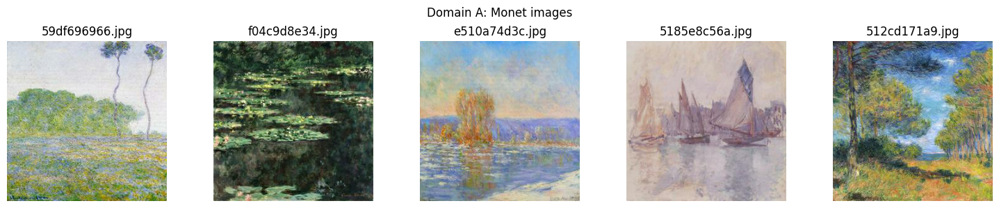

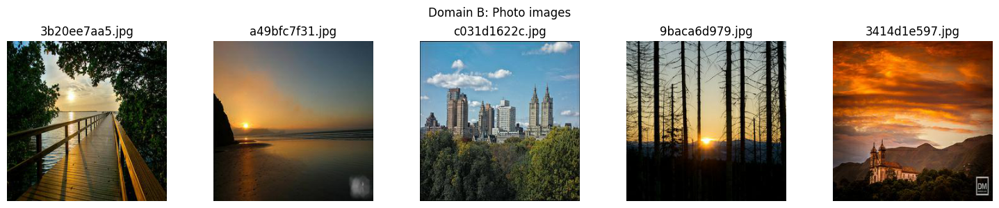

In [9]:
def show_dataset_examples(paths, title, count=5):
    count = min(count, len(paths))
    selected = random.Random(SEED).sample(paths, count)

    plt.figure(figsize=(15, 3))
    for index, path in enumerate(selected):
        image = Image.open(path).convert("RGB")
        plt.subplot(1, count, index + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(path.name[:15])
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_dataset_examples(monet_paths, "Domain A: Monet images")
show_dataset_examples(photo_paths, "Domain B: Photo images")

## 6. Training settings

The smoke test runs only 20 steps. Run 3 uses 120,000 steps, batch size 1, and mixed precision.

Changes compared with Run 1:

- **DiffAugment** (color, translation, cutout) is applied to every image the discriminators see. The Monet domain has only 300 images, so the discriminators overfit them within a few thousand steps. DiffAugment keeps them useful for longer.
- **EMA generators** (decay 0.999) are used for all sample images, metrics, and the Kaggle package. Averaging the generator weights removes step-to-step noise.
- **120,000 steps** (60,000 constant + 60,000 linear decay) instead of 100,000.
- The generator keeps the Run 1 `ConvTranspose2d` upsampling. Run 2's bilinear upsampling gave a worse FID.

In [10]:
RUN_MODE = "full"                 # Change to "full" after the smoke test works.
RESUME_TRAINING = True

IMAGE_SIZE = 256
RESIZE_SIZE = 286
BATCH_SIZE = 1
NUM_WORKERS = 4

LEARNING_RATE = 0.0002
BETA1 = 0.5
BETA2 = 0.999

LAMBDA_CYCLE = 10.0
LAMBDA_IDENTITY = 5.0
MAX_GRAD_NORM = 10.0

# Run 3 additions
USE_DIFFAUG = True
DIFFAUG_POLICY = "color,translation,cutout"
USE_EMA = True
EMA_DECAY = 0.999

if RUN_MODE == "smoke":
    MAX_STEPS = 20
    DECAY_START_STEP = 10
    LOG_EVERY = 1
    SAMPLE_EVERY = 10
    CHECKPOINT_EVERY = 10
    EVAL_IMAGES = 20
else:
    MAX_STEPS = 120_000
    DECAY_START_STEP = 60_000
    LOG_EVERY = 100
    SAMPLE_EVERY = 5_000
    CHECKPOINT_EVERY = 10_000
    EVAL_IMAGES = 300

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

print("Run mode:", RUN_MODE)
print("Device:", DEVICE)
print("Maximum training steps:", MAX_STEPS)
print("DiffAugment:", USE_DIFFAUG, DIFFAUG_POLICY)
print("Generator EMA:", USE_EMA, EMA_DECAY)

if DEVICE.type == "cuda":
    gpu = torch.cuda.get_device_properties(0)
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory (GB):", round(gpu.total_memory / 1024**3, 2))
    print("CUDA version:", torch.version.cuda)
else:
    print("WARNING: A GPU was not detected.")

Run mode: full
Device: cuda
Maximum training steps: 120000
DiffAugment: True color,translation,cutout
Generator EMA: True 0.999
GPU: NVIDIA GeForce RTX 4090
GPU memory (GB): 23.99
CUDA version: 12.1


## 7. Unpaired dataset and data loader

The Monet image uses the current shuffled index. The photo is selected independently at random. Therefore, the code does not create false one-to-one pairs.

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


class UnpairedImageDataset(Dataset):
    def __init__(self, domain_a_paths, domain_b_paths, transform):
        self.domain_a_paths = domain_a_paths
        self.domain_b_paths = domain_b_paths
        self.transform = transform

    def __len__(self):
        return max(len(self.domain_a_paths), len(self.domain_b_paths))

    def __getitem__(self, index):
        a_path = self.domain_a_paths[index % len(self.domain_a_paths)]
        b_path = random.choice(self.domain_b_paths)

        image_a = Image.open(a_path).convert("RGB")
        image_b = Image.open(b_path).convert("RGB")

        return {
            "A": self.transform(image_a),
            "B": self.transform(image_b),
            "A_path": str(a_path),
            "B_path": str(b_path),
        }


train_dataset = UnpairedImageDataset(monet_paths, photo_paths, train_transform)

train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
    generator=train_generator,
)

print("Training batches in one pass:", len(train_loader))

Training batches in one pass: 7038


## 8. CycleGAN models

The generator uses nine residual blocks, which is the standard CycleGAN choice for 256×256 images. Upsampling uses `ConvTranspose2d`, as in Run 1. The discriminator is a PatchGAN: it judges small image regions instead of returning only one score for the complete image.

In [12]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, kernel_size=3),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, kernel_size=3),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)


class Generator(nn.Module):
    def __init__(self, number_of_residual_blocks=9):
        super().__init__()

        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(3, 64, kernel_size=7),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),
        ]

        # Downsample: 256 -> 128 -> 64
        input_channels = 64
        for output_channels in [128, 256]:
            layers += [
                nn.Conv2d(input_channels, output_channels, kernel_size=3, stride=2, padding=1),
                nn.InstanceNorm2d(output_channels),
                nn.ReLU(inplace=True),
            ]
            input_channels = output_channels

        # Keep the 64 x 64 feature map and learn the translation.
        for _ in range(number_of_residual_blocks):
            layers.append(ResidualBlock(256))

        # Upsample: 64 -> 128 -> 256
        for output_channels in [128, 64]:
            layers += [
                nn.ConvTranspose2d(
                    input_channels,
                    output_channels,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1,
                ),
                nn.InstanceNorm2d(output_channels),
                nn.ReLU(inplace=True),
            ]
            input_channels = output_channels

        layers += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, 3, kernel_size=7),
            nn.Tanh(),
        ]

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        def block(input_channels, output_channels, normalize=True):
            layers = [
                nn.Conv2d(input_channels, output_channels, kernel_size=4, stride=2, padding=1)
            ]
            if normalize:
                layers.append(nn.InstanceNorm2d(output_channels))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(3, 64, normalize=False),
            *block(64, 128),
            *block(128, 256),
            nn.Conv2d(256, 512, kernel_size=4, stride=1, padding=1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1),
        )

    def forward(self, x):
        return self.model(x)


def initialize_weights(module):
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(module.weight.data, 0.0, 0.02)
        if module.bias is not None:
            nn.init.constant_(module.bias.data, 0.0)

In [13]:
G_A2B = Generator().to(DEVICE)  # Monet -> Photo
G_B2A = Generator().to(DEVICE)  # Photo -> Monet
D_A = Discriminator().to(DEVICE)  # Checks Monet images
D_B = Discriminator().to(DEVICE)  # Checks photo images

G_A2B.apply(initialize_weights)
G_B2A.apply(initialize_weights)
D_A.apply(initialize_weights)
D_B.apply(initialize_weights)


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


parameter_counts = {
    "G_A2B": count_parameters(G_A2B),
    "G_B2A": count_parameters(G_B2A),
    "D_A": count_parameters(D_A),
    "D_B": count_parameters(D_B),
}

for name, count in parameter_counts.items():
    print(f"{name} parameters: {count:,}")

print("Total trainable parameters:", f"{sum(parameter_counts.values()):,}")

G_A2B parameters: 11,378,179
G_B2A parameters: 11,378,179
D_A parameters: 2,764,737
D_B parameters: 2,764,737
Total trainable parameters: 28,285,832


## 9. Losses, optimizers, learning-rate schedule, and replay buffer

- Adversarial loss makes translated images look real in the target domain.
- Cycle loss checks that translating forward and backward reconstructs the input.
- Identity loss helps preserve unnecessary color and structure changes.
- The replay buffer mixes recent and older generated images to improve discriminator stability.
- DiffAugment randomly changes color, position, and masks part of every image before it enters a discriminator. It is differentiable, so the generators still receive gradients through it.
- The EMA generators keep a slowly moving average of the generator weights. They are not trained directly.

In [14]:
gan_loss = nn.MSELoss()
cycle_loss = nn.L1Loss()
identity_loss = nn.L1Loss()

optimizer_G = torch.optim.Adam(
    list(G_A2B.parameters()) + list(G_B2A.parameters()),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2),
)

optimizer_D = torch.optim.Adam(
    list(D_A.parameters()) + list(D_B.parameters()),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2),
)


def learning_rate_multiplier(step):
    if step < DECAY_START_STEP:
        return 1.0
    remaining = MAX_STEPS - step
    decay_length = max(1, MAX_STEPS - DECAY_START_STEP)
    return max(0.0, remaining / decay_length)


scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, learning_rate_multiplier)
scheduler_D = torch.optim.lr_scheduler.LambdaLR(optimizer_D, learning_rate_multiplier)

scaler_G = torch.cuda.amp.GradScaler(enabled=USE_AMP)
scaler_D = torch.cuda.amp.GradScaler(enabled=USE_AMP)


class ImageReplayBuffer:
    def __init__(self, maximum_size=50):
        self.maximum_size = maximum_size
        self.images = []

    def get_images(self, new_images):
        returned_images = []

        for image in new_images.detach():
            image = image.unsqueeze(0)

            if len(self.images) < self.maximum_size:
                self.images.append(image)
                returned_images.append(image)
            elif random.random() > 0.5:
                old_index = random.randrange(self.maximum_size)
                old_image = self.images[old_index].clone()
                self.images[old_index] = image
                returned_images.append(old_image)
            else:
                returned_images.append(image)

        return torch.cat(returned_images, dim=0)


fake_a_buffer = ImageReplayBuffer()
fake_b_buffer = ImageReplayBuffer()

# ---------------------------------------------------------
# DiffAugment (Zhao et al., 2020), applied to discriminator inputs only
# ---------------------------------------------------------
def _rand_brightness(x):
    return x + (torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) - 0.5)


def _rand_saturation(x):
    x_mean = x.mean(dim=1, keepdim=True)
    factor = torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) * 2
    return (x - x_mean) * factor + x_mean


def _rand_contrast(x):
    x_mean = x.mean(dim=[1, 2, 3], keepdim=True)
    factor = torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) + 0.5
    return (x - x_mean) * factor + x_mean


def _rand_translation(x, ratio=0.125):
    n, _, h, w = x.shape
    shift_x, shift_y = int(h * ratio + 0.5), int(w * ratio + 0.5)
    translation_x = torch.randint(-shift_x, shift_x + 1, size=[n, 1, 1], device=x.device)
    translation_y = torch.randint(-shift_y, shift_y + 1, size=[n, 1, 1], device=x.device)
    grid_batch, grid_x, grid_y = torch.meshgrid(
        torch.arange(n, dtype=torch.long, device=x.device),
        torch.arange(h, dtype=torch.long, device=x.device),
        torch.arange(w, dtype=torch.long, device=x.device),
        indexing="ij",
    )
    grid_x = torch.clamp(grid_x + translation_x + 1, 0, h + 1)
    grid_y = torch.clamp(grid_y + translation_y + 1, 0, w + 1)
    x_padded = F.pad(x, [1, 1, 1, 1, 0, 0, 0, 0])
    return x_padded.permute(0, 2, 3, 1).contiguous()[grid_batch, grid_x, grid_y].permute(0, 3, 1, 2)


def _rand_cutout(x, ratio=0.5):
    n, _, h, w = x.shape
    cut_h, cut_w = int(h * ratio + 0.5), int(w * ratio + 0.5)
    offset_x = torch.randint(0, h + (1 - cut_h % 2), size=[n, 1, 1], device=x.device)
    offset_y = torch.randint(0, w + (1 - cut_w % 2), size=[n, 1, 1], device=x.device)
    grid_batch, grid_x, grid_y = torch.meshgrid(
        torch.arange(n, dtype=torch.long, device=x.device),
        torch.arange(cut_h, dtype=torch.long, device=x.device),
        torch.arange(cut_w, dtype=torch.long, device=x.device),
        indexing="ij",
    )
    grid_x = torch.clamp(grid_x + offset_x - cut_h // 2, min=0, max=h - 1)
    grid_y = torch.clamp(grid_y + offset_y - cut_w // 2, min=0, max=w - 1)
    mask = torch.ones(n, h, w, dtype=x.dtype, device=x.device)
    mask[grid_batch, grid_x, grid_y] = 0
    return x * mask.unsqueeze(1)


DIFFAUG_FUNCTIONS = {
    "color": [_rand_brightness, _rand_saturation, _rand_contrast],
    "translation": [_rand_translation],
    "cutout": [_rand_cutout],
}


def diff_augment(x):
    if not USE_DIFFAUG:
        return x
    for policy_name in DIFFAUG_POLICY.split(","):
        for augment_function in DIFFAUG_FUNCTIONS[policy_name]:
            x = augment_function(x)
    return x.contiguous()


# ---------------------------------------------------------
# EMA copies of the generators
# ---------------------------------------------------------
G_A2B_ema = copy.deepcopy(G_A2B).eval()
G_B2A_ema = copy.deepcopy(G_B2A).eval()

for ema_model in (G_A2B_ema, G_B2A_ema):
    for parameter in ema_model.parameters():
        parameter.requires_grad_(False)


@torch.no_grad()
def update_ema(ema_model, model, decay=EMA_DECAY):
    for ema_parameter, parameter in zip(ema_model.parameters(), model.parameters()):
        ema_parameter.mul_(decay).add_(parameter.detach(), alpha=1.0 - decay)

## 10. Helper functions for samples and checkpoints

In [15]:
def tensor_to_display_image(tensor):
    image = tensor.detach().cpu().squeeze(0)
    image = (image * 0.5 + 0.5).clamp(0, 1)
    return image.permute(1, 2, 0).numpy()


@torch.no_grad()
def save_sample_figure(step, real_a, real_b):
    G_A2B.eval()
    G_B2A.eval()

    fake_b = G_A2B(real_a)
    reconstructed_a = G_B2A(fake_b)

    fake_a = G_B2A(real_b)
    reconstructed_b = G_A2B(fake_a)

    images = [real_a, fake_b, reconstructed_a, real_b, fake_a, reconstructed_b]
    titles = [
        "Real Monet",
        "Monet to Photo",
        "Reconstructed Monet",
        "Real Photo",
        "Photo to Monet",
        "Reconstructed Photo",
    ]

    plt.figure(figsize=(15, 7))
    for index, (image, title) in enumerate(zip(images, titles)):
        plt.subplot(2, 3, index + 1)
        plt.imshow(tensor_to_display_image(image))
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    figure_path = FIGURE_DIR / f"training_sample_step_{step:06d}.png"
    plt.savefig(figure_path, dpi=150, bbox_inches="tight")
    plt.show()

    G_A2B.train()
    G_B2A.train()

    print("Saved sample figure:", figure_path)


def save_checkpoint(step, training_history, nan_count, elapsed_seconds, images_seen):
    checkpoint = {
        "step": step,
        "G_A2B": G_A2B.state_dict(),
        "G_B2A": G_B2A.state_dict(),
        "D_A": D_A.state_dict(),
        "D_B": D_B.state_dict(),
        "G_A2B_ema": G_A2B_ema.state_dict(),
        "G_B2A_ema": G_B2A_ema.state_dict(),
        "optimizer_G": optimizer_G.state_dict(),
        "optimizer_D": optimizer_D.state_dict(),
        "scheduler_G": scheduler_G.state_dict(),
        "scheduler_D": scheduler_D.state_dict(),
        "scaler_G": scaler_G.state_dict(),
        "scaler_D": scaler_D.state_dict(),
        "training_history": training_history,
        "nan_count": nan_count,
        "elapsed_seconds": elapsed_seconds,
        "images_seen": images_seen,
        "settings": {
            "seed": SEED,
            "image_size": IMAGE_SIZE,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "lambda_cycle": LAMBDA_CYCLE,
            "lambda_identity": LAMBDA_IDENTITY,
            "max_steps": MAX_STEPS,
            "diffaug_policy": DIFFAUG_POLICY if USE_DIFFAUG else None,
            "ema_decay": EMA_DECAY if USE_EMA else None,
        },
    }

    numbered_path = CHECKPOINT_DIR / f"cyclegan_step_{step:06d}.pt"
    latest_path = CHECKPOINT_DIR / "cyclegan_latest.pt"

    torch.save(checkpoint, numbered_path)
    torch.save(checkpoint, latest_path)

    print("Saved checkpoint:", numbered_path)


def load_latest_checkpoint():
    latest_path = CHECKPOINT_DIR / "cyclegan_latest.pt"

    if not RESUME_TRAINING or not latest_path.exists():
        return 0, [], 0, 0.0, 0

    checkpoint = torch.load(latest_path, map_location=DEVICE, weights_only=False)

    G_A2B.load_state_dict(checkpoint["G_A2B"])
    G_B2A.load_state_dict(checkpoint["G_B2A"])
    D_A.load_state_dict(checkpoint["D_A"])
    D_B.load_state_dict(checkpoint["D_B"])
    if "G_A2B_ema" in checkpoint:
        G_A2B_ema.load_state_dict(checkpoint["G_A2B_ema"])
        G_B2A_ema.load_state_dict(checkpoint["G_B2A_ema"])

    optimizer_G.load_state_dict(checkpoint["optimizer_G"])
    optimizer_D.load_state_dict(checkpoint["optimizer_D"])
    scheduler_G.load_state_dict(checkpoint["scheduler_G"])
    scheduler_D.load_state_dict(checkpoint["scheduler_D"])
    scaler_G.load_state_dict(checkpoint["scaler_G"])
    scaler_D.load_state_dict(checkpoint["scaler_D"])

    print("Resuming from step:", checkpoint["step"])

    return (
        checkpoint["step"],
        checkpoint.get("training_history", []),
        checkpoint.get("nan_count", 0),
        checkpoint.get("elapsed_seconds", 0.0),
        checkpoint.get("images_seen", 0),
    )

## 11. Train the CycleGAN

This is the main training cell. It records all required losses, gradient norms, NaN counts, speed, time, and peak GPU memory.

Resuming from step: 90000


Training:   0%|          | 101/30000 [00:10<38:09, 13.06it/s, D=0.274, G=2.865, cycle=0.123] 

Step 90100/120000 | G: 3.1651 | D: 0.2960 | Cycle A: 0.0624 | Cycle B: 0.1116 | Grad G: 23.2019 | Grad D: 5.3108 | NaNs: 0


Training:   1%|          | 201/30000 [00:18<38:02, 13.05it/s, D=0.520, G=3.615, cycle=0.182]

Step 90200/120000 | G: 2.3462 | D: 0.4638 | Cycle A: 0.0587 | Cycle B: 0.0797 | Grad G: 17.0794 | Grad D: 12.5099 | NaNs: 0


...

Step 94800/120000 | G: 2.5455 | D: 0.3492 | Cycle A: 0.0670 | Cycle B: 0.0557 | Grad G: 20.7292 | Grad D: 5.2307 | NaNs: 0


Training:  16%|█▋        | 4901/30000 [06:45<36:04, 11.59it/s, D=0.294, G=2.517, cycle=0.110]

Step 94900/120000 | G: 2.2075 | D: 0.3629 | Cycle A: 0.0582 | Cycle B: 0.0563 | Grad G: 20.1086 | Grad D: 6.4189 | NaNs: 0


Training:  17%|█▋        | 4999/30000 [06:53<32:47, 12.71it/s, D=0.490, G=3.039, cycle=0.146]

Step 95000/120000 | G: 3.0387 | D: 0.4900 | Cycle A: 0.0532 | Cycle B: 0.0926 | Grad G: 21.9470 | Grad D: 7.9919 | NaNs: 0


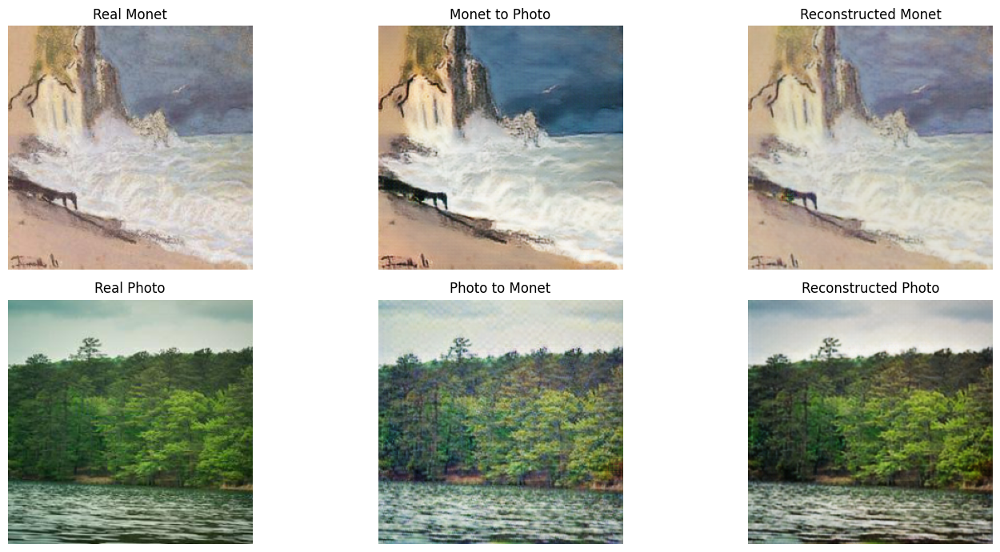

Training:  17%|█▋        | 5001/30000 [06:55<2:36:55,  2.66it/s, D=0.312, G=3.272, cycle=0.138]

Saved sample figure: /app/task3_cyclegan_run3_diffaug_ema/outputs/figures/training_sample_step_095000.png


Training:  17%|█▋        | 5101/30000 [07:03<34:11, 12.14it/s, D=0.374, G=2.665, cycle=0.111]  

Step 95100/120000 | G: 2.5439 | D: 0.4614 | Cycle A: 0.0564 | Cycle B: 0.0730 | Grad G: 17.9123 | Grad D: 6.8604 | NaNs: 0


Training:  17%|█▋        | 5201/30000 [07:11<33:07, 12.48it/s, D=0.450, G=2.781, cycle=0.134]

...

Step 99800/120000 | G: 2.7848 | D: 0.4383 | Cycle A: 0.0544 | Cycle B: 0.0702 | Grad G: 21.2276 | Grad D: 5.9294 | NaNs: 0


Training:  33%|███▎      | 9901/30000 [13:41<27:39, 12.11it/s, D=0.603, G=2.771, cycle=0.139]

Step 99900/120000 | G: 2.7076 | D: 0.3902 | Cycle A: 0.0767 | Cycle B: 0.0563 | Grad G: 14.2209 | Grad D: 11.9857 | NaNs: 0


Training:  33%|███▎      | 9999/30000 [13:50<30:07, 11.06it/s, D=0.175, G=4.291, cycle=0.147]

Step 100000/120000 | G: 4.2913 | D: 0.1749 | Cycle A: 0.0687 | Cycle B: 0.0780 | Grad G: 97.3940 | Grad D: 4.5920 | NaNs: 0


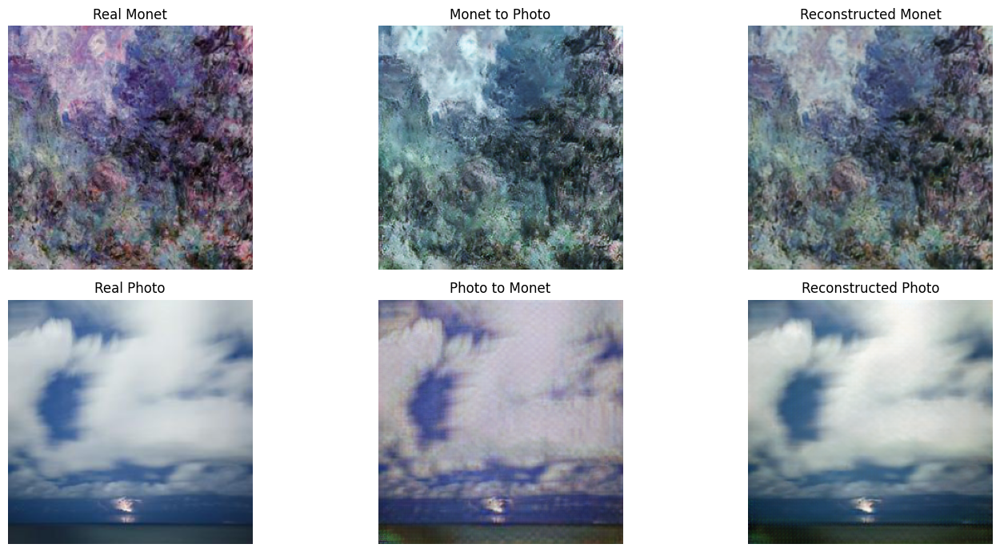

Saved sample figure: /app/task3_cyclegan_run3_diffaug_ema/outputs/figures/training_sample_step_100000.png
Saved checkpoint: /app/task3_cyclegan_run3_diffaug_ema/checkpoints/cyclegan_step_100000.pt


Training:  34%|███▎      | 10101/30000 [14:03<29:11, 11.36it/s, D=0.469, G=2.251, cycle=0.108]  

Step 100100/120000 | G: 2.6958 | D: 0.6540 | Cycle A: 0.0660 | Cycle B: 0.0700 | Grad G: 17.2046 | Grad D: 10.5828 | NaNs: 0


Training:  34%|███▍      | 10201/30000 [14:12<28:20, 11.64it/s, D=0.206, G=2.688, cycle=0.113]

Step 100200/120000 | G: 2.2762 | D: 0.4892 | Cycle A: 0.0439 | Cycle B: 0.0776 | Grad G: 19.3955 | Grad D: 10.1746 | NaNs: 0


...

Step 104800/120000 | G: 2.8264 | D: 0.2616 | Cycle A: 0.0346 | Cycle B: 0.0898 | Grad G: 24.4480 | Grad D: 6.8900 | NaNs: 0


Training:  50%|████▉     | 14901/30000 [20:45<21:19, 11.80it/s, D=0.451, G=2.350, cycle=0.122]

Step 104900/120000 | G: 2.3457 | D: 0.3643 | Cycle A: 0.0547 | Cycle B: 0.0436 | Grad G: 24.2301 | Grad D: 6.6420 | NaNs: 0


Training:  50%|████▉     | 14999/30000 [20:53<20:28, 12.21it/s, D=0.490, G=2.652, cycle=0.120]

Step 105000/120000 | G: 2.6517 | D: 0.4901 | Cycle A: 0.0553 | Cycle B: 0.0648 | Grad G: 21.7690 | Grad D: 5.7829 | NaNs: 0


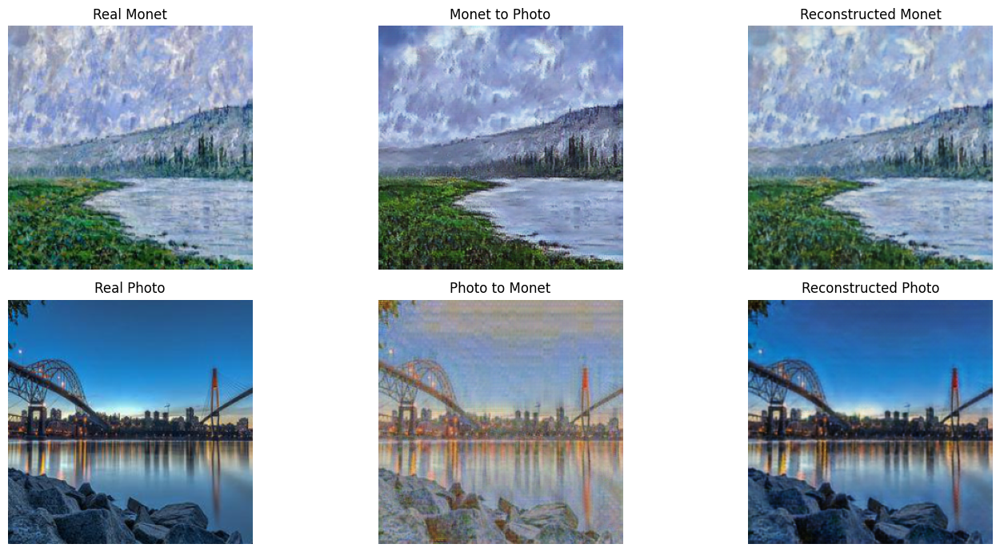

Training:  50%|█████     | 15001/30000 [20:54<51:36,  4.84it/s, D=0.268, G=2.613, cycle=0.091]

Saved sample figure: /app/task3_cyclegan_run3_diffaug_ema/outputs/figures/training_sample_step_105000.png


Training:  50%|█████     | 15101/30000 [21:02<22:33, 11.00it/s, D=0.313, G=2.574, cycle=0.104]

Step 105100/120000 | G: 2.9301 | D: 0.5253 | Cycle A: 0.0966 | Cycle B: 0.0602 | Grad G: 18.6205 | Grad D: 17.1494 | NaNs: 0


Training:  51%|█████     | 15201/30000 [21:11<22:15, 11.08it/s, D=0.225, G=2.294, cycle=0.116]

...

Step 109800/120000 | G: 4.5317 | D: 0.1444 | Cycle A: 0.0858 | Cycle B: 0.1496 | Grad G: 31.4681 | Grad D: 5.9234 | NaNs: 0


Training:  66%|██████▋   | 19901/30000 [27:50<14:19, 11.75it/s, D=0.340, G=2.421, cycle=0.107]

Step 109900/120000 | G: 2.9526 | D: 0.3685 | Cycle A: 0.0559 | Cycle B: 0.0863 | Grad G: 20.0579 | Grad D: 7.8037 | NaNs: 0


Training:  67%|██████▋   | 19999/30000 [27:59<14:15, 11.69it/s, D=0.508, G=1.909, cycle=0.081]

Step 110000/120000 | G: 1.9085 | D: 0.5076 | Cycle A: 0.0436 | Cycle B: 0.0373 | Grad G: 10.9742 | Grad D: 9.0928 | NaNs: 0


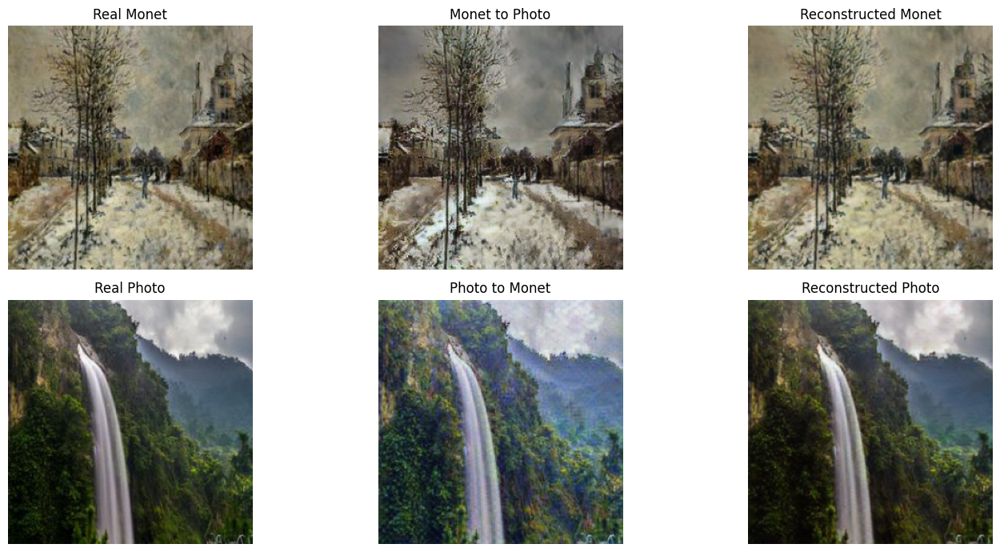

Saved sample figure: /app/task3_cyclegan_run3_diffaug_ema/outputs/figures/training_sample_step_110000.png
Saved checkpoint: /app/task3_cyclegan_run3_diffaug_ema/checkpoints/cyclegan_step_110000.pt


Training:  67%|██████▋   | 20101/30000 [28:13<14:42, 11.21it/s, D=0.640, G=2.245, cycle=0.109]  

Step 110100/120000 | G: 2.2706 | D: 0.5129 | Cycle A: 0.0377 | Cycle B: 0.0506 | Grad G: 11.8341 | Grad D: 9.3716 | NaNs: 0


Training:  67%|██████▋   | 20201/30000 [28:22<13:23, 12.19it/s, D=0.268, G=2.604, cycle=0.088]

Step 110200/120000 | G: 2.3441 | D: 0.3236 | Cycle A: 0.0584 | Cycle B: 0.0638 | Grad G: 27.9055 | Grad D: 13.8642 | NaNs: 0


...

Step 114800/120000 | G: 3.3963 | D: 0.3254 | Cycle A: 0.0420 | Cycle B: 0.0801 | Grad G: 41.4103 | Grad D: 9.9460 | NaNs: 0


Training:  83%|████████▎ | 24901/30000 [35:00<07:17, 11.66it/s, D=0.270, G=2.350, cycle=0.094] 

Step 114900/120000 | G: 4.6734 | D: 0.4585 | Cycle A: 0.0457 | Cycle B: 0.1971 | Grad G: 32.1384 | Grad D: 21.4444 | NaNs: 0


Training:  83%|████████▎ | 24999/30000 [35:08<07:09, 11.65it/s, D=0.578, G=3.201, cycle=0.158]

Step 115000/120000 | G: 3.2014 | D: 0.5780 | Cycle A: 0.0511 | Cycle B: 0.1067 | Grad G: 16.3883 | Grad D: 11.5914 | NaNs: 0


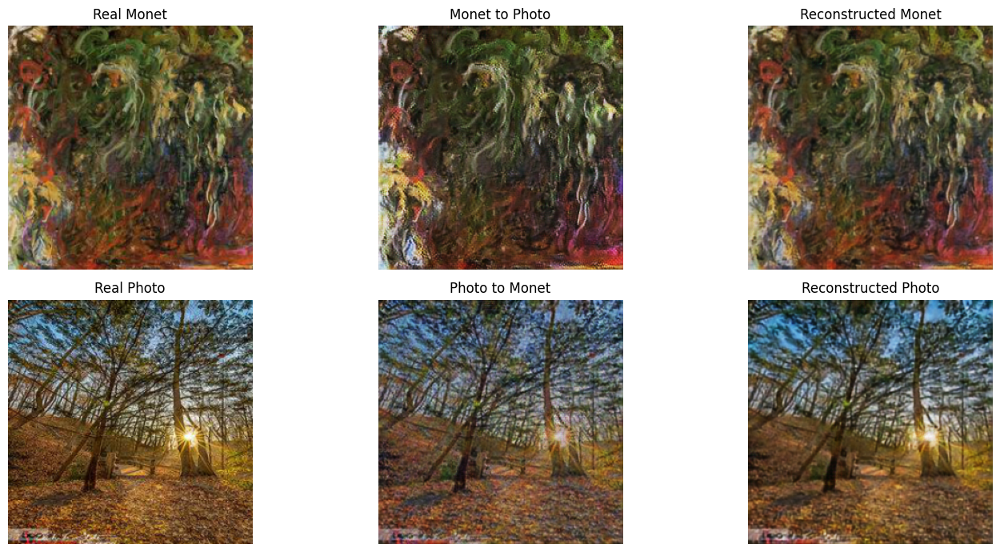

Training:  83%|████████▎ | 25001/30000 [35:09<20:14,  4.12it/s, D=0.286, G=2.297, cycle=0.107]

Saved sample figure: /app/task3_cyclegan_run3_diffaug_ema/outputs/figures/training_sample_step_115000.png


Training:  84%|████████▎ | 25101/30000 [35:18<06:46, 12.05it/s, D=0.570, G=2.625, cycle=0.152]

Step 115100/120000 | G: 2.9493 | D: 0.3072 | Cycle A: 0.0398 | Cycle B: 0.0964 | Grad G: 32.5793 | Grad D: 7.8697 | NaNs: 0


Training:  84%|████████▍ | 25201/30000 [35:27<06:56, 11.53it/s, D=0.552, G=2.047, cycle=0.075]

...

Step 119800/120000 | G: 2.5084 | D: 0.4303 | Cycle A: 0.0355 | Cycle B: 0.0931 | Grad G: 19.8858 | Grad D: 10.7712 | NaNs: 0


Training: 100%|█████████▉| 29901/30000 [42:12<00:08, 11.21it/s, D=0.404, G=3.120, cycle=0.146]

Step 119900/120000 | G: 2.6481 | D: 0.3744 | Cycle A: 0.0436 | Cycle B: 0.0830 | Grad G: 44.8287 | Grad D: 10.5859 | NaNs: 0


Training: 100%|█████████▉| 29999/30000 [42:20<00:00, 11.85it/s, D=0.209, G=2.487, cycle=0.106]

Step 120000/120000 | G: 2.4873 | D: 0.2087 | Cycle A: 0.0446 | Cycle B: 0.0611 | Grad G: 31.9317 | Grad D: 6.7879 | NaNs: 0


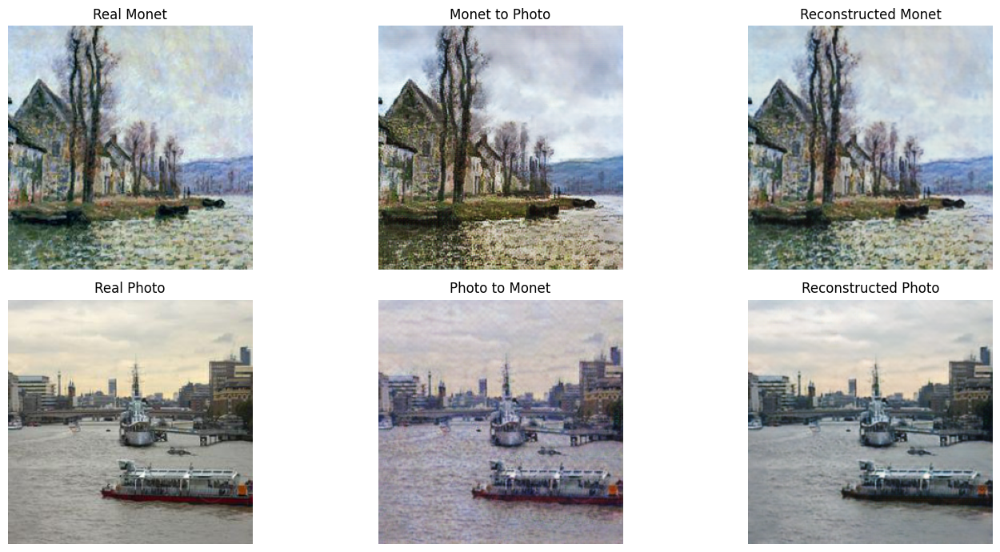

Saved sample figure: /app/task3_cyclegan_run3_diffaug_ema/outputs/figures/training_sample_step_120000.png


Training: 100%|██████████| 30000/30000 [42:26<00:00, 11.78it/s, D=0.209, G=2.487, cycle=0.106]

Saved checkpoint: /app/task3_cyclegan_run3_diffaug_ema/checkpoints/cyclegan_step_120000.pt


EMA generator weights are now loaded into G_A2B and G_B2A.
Training finished
Training time (hours): 2.897
Images per second: 23.014
Peak allocated GPU memory (GB): 16.873
NaN count: 0
Training history: /app/task3_cyclegan_run3_diffaug_ema/training_history.csv


In [16]:
start_step, training_history, nan_count, earlier_seconds, images_seen = load_latest_checkpoint()

G_A2B.train()
G_B2A.train()
D_A.train()
D_B.train()

if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

training_start_time = time.time()
data_iterator = iter(train_loader)

progress_bar = tqdm(range(start_step + 1, MAX_STEPS + 1), desc="Training")

for step in progress_bar:
    try:
        batch = next(data_iterator)
    except StopIteration:
        data_iterator = iter(train_loader)
        batch = next(data_iterator)

    real_a = batch["A"].to(DEVICE, non_blocking=True)
    real_b = batch["B"].to(DEVICE, non_blocking=True)

    # ---------------------------------------------------------
    # 1. Train both generators
    # ---------------------------------------------------------
    optimizer_G.zero_grad(set_to_none=True)

    with torch.cuda.amp.autocast(enabled=USE_AMP):
        fake_b = G_A2B(real_a)
        reconstructed_a = G_B2A(fake_b)

        fake_a = G_B2A(real_b)
        reconstructed_b = G_A2B(fake_a)

        identity_a = G_B2A(real_a)
        identity_b = G_A2B(real_b)

        prediction_fake_b = D_B(diff_augment(fake_b))
        prediction_fake_a = D_A(diff_augment(fake_a))

        loss_gan_a2b = gan_loss(prediction_fake_b, torch.ones_like(prediction_fake_b))
        loss_gan_b2a = gan_loss(prediction_fake_a, torch.ones_like(prediction_fake_a))

        loss_cycle_a = cycle_loss(reconstructed_a, real_a)
        loss_cycle_b = cycle_loss(reconstructed_b, real_b)

        loss_identity_a = identity_loss(identity_a, real_a)
        loss_identity_b = identity_loss(identity_b, real_b)

        loss_G = (
            loss_gan_a2b
            + loss_gan_b2a
            + LAMBDA_CYCLE * (loss_cycle_a + loss_cycle_b)
            + LAMBDA_IDENTITY * (loss_identity_a + loss_identity_b)
        )

    if not torch.isfinite(loss_G):
        nan_count += 1
        optimizer_G.zero_grad(set_to_none=True)
        print(f"Non-finite generator loss at step {step}. Step skipped.")
        continue

    scaler_G.scale(loss_G).backward()
    scaler_G.unscale_(optimizer_G)
    grad_norm_G = torch.nn.utils.clip_grad_norm_(
        list(G_A2B.parameters()) + list(G_B2A.parameters()),
        MAX_GRAD_NORM,
    )
    scaler_G.step(optimizer_G)
    scaler_G.update()

    if USE_EMA:
        update_ema(G_A2B_ema, G_A2B)
        update_ema(G_B2A_ema, G_B2A)

    # ---------------------------------------------------------
    # 2. Train both discriminators
    # ---------------------------------------------------------
    optimizer_D.zero_grad(set_to_none=True)

    buffered_fake_a = fake_a_buffer.get_images(fake_a)
    buffered_fake_b = fake_b_buffer.get_images(fake_b)

    with torch.amp.autocast("cuda", enabled=USE_AMP):
        prediction_real_a = D_A(diff_augment(real_a))
        prediction_fake_a = D_A(diff_augment(buffered_fake_a.detach()))
        loss_D_A = 0.5 * (
            gan_loss(prediction_real_a, torch.ones_like(prediction_real_a))
            + gan_loss(prediction_fake_a, torch.zeros_like(prediction_fake_a))
        )

        prediction_real_b = D_B(diff_augment(real_b))
        prediction_fake_b = D_B(diff_augment(buffered_fake_b.detach()))
        loss_D_B = 0.5 * (
            gan_loss(prediction_real_b, torch.ones_like(prediction_real_b))
            + gan_loss(prediction_fake_b, torch.zeros_like(prediction_fake_b))
        )

        loss_D = loss_D_A + loss_D_B

    if not torch.isfinite(loss_D):
        nan_count += 1
        optimizer_D.zero_grad(set_to_none=True)
        print(f"Non-finite discriminator loss at step {step}. Step skipped.")
        continue

    scaler_D.scale(loss_D).backward()
    scaler_D.unscale_(optimizer_D)
    grad_norm_D = torch.nn.utils.clip_grad_norm_(
        list(D_A.parameters()) + list(D_B.parameters()),
        MAX_GRAD_NORM,
    )
    scaler_D.step(optimizer_D)
    scaler_D.update()

    scheduler_G.step()
    scheduler_D.step()

    images_seen += real_a.size(0) + real_b.size(0)

    current_record = {
        "step": step,
        "loss_G": float(loss_G.item()),
        "loss_D": float(loss_D.item()),
        "loss_D_A": float(loss_D_A.item()),
        "loss_D_B": float(loss_D_B.item()),
        "loss_gan_A2B": float(loss_gan_a2b.item()),
        "loss_gan_B2A": float(loss_gan_b2a.item()),
        "cycle_A": float(loss_cycle_a.item()),
        "cycle_B": float(loss_cycle_b.item()),
        "identity_A": float(loss_identity_a.item()),
        "identity_B": float(loss_identity_b.item()),
        "grad_norm_G": float(grad_norm_G.item()),
        "grad_norm_D": float(grad_norm_D.item()),
        "learning_rate_G": optimizer_G.param_groups[0]["lr"],
        "learning_rate_D": optimizer_D.param_groups[0]["lr"],
        "nan_count": nan_count,
    }
    training_history.append(current_record)

    progress_bar.set_postfix(
        G=f"{loss_G.item():.3f}",
        D=f"{loss_D.item():.3f}",
        cycle=f"{(loss_cycle_a + loss_cycle_b).item():.3f}",
    )

    if step % LOG_EVERY == 0:
        print(
            f"Step {step}/{MAX_STEPS} | "
            f"G: {loss_G.item():.4f} | D: {loss_D.item():.4f} | "
            f"Cycle A: {loss_cycle_a.item():.4f} | Cycle B: {loss_cycle_b.item():.4f} | "
            f"Grad G: {grad_norm_G.item():.4f} | Grad D: {grad_norm_D.item():.4f} | "
            f"NaNs: {nan_count}"
        )

    if step % SAMPLE_EVERY == 0 or step == MAX_STEPS:
        save_sample_figure(step, real_a[:1], real_b[:1])

    if step % CHECKPOINT_EVERY == 0 or step == MAX_STEPS:
        current_seconds = earlier_seconds + (time.time() - training_start_time)
        save_checkpoint(step, training_history, nan_count, current_seconds, images_seen)


# Use the EMA generators for every result below (samples, metrics, Kaggle package).
# The raw training weights stay saved inside the checkpoints.
if USE_EMA:
    torch.save(
        {"G_A2B_raw": G_A2B.state_dict(), "G_B2A_raw": G_B2A.state_dict(),
         "G_A2B_ema": G_A2B_ema.state_dict(), "G_B2A_ema": G_B2A_ema.state_dict()},
        CHECKPOINT_DIR / "generators_final_raw_and_ema.pt",
    )
    G_A2B.load_state_dict(G_A2B_ema.state_dict())
    G_B2A.load_state_dict(G_B2A_ema.state_dict())
    G_A2B.eval()
    G_B2A.eval()
    print("EMA generator weights are now loaded into G_A2B and G_B2A.")

total_training_seconds = earlier_seconds + (time.time() - training_start_time)
training_hours = total_training_seconds / 3600
images_per_second = images_seen / max(total_training_seconds, 1e-8)

if DEVICE.type == "cuda":
    peak_memory_gb = torch.cuda.max_memory_allocated() / 1024**3
else:
    peak_memory_gb = 0.0

history_df = pd.DataFrame(training_history)
history_path = PROJECT_DIR / "training_history.csv"
history_df.to_csv(history_path, index=False)

print("Training finished")
print("Training time (hours):", round(training_hours, 3))
print("Images per second:", round(images_per_second, 3))
print("Peak allocated GPU memory (GB):", round(peak_memory_gb, 3))
print("NaN count:", nan_count)
print("Training history:", history_path)

## 12. Plot the training behavior

GAN losses do not need to fall smoothly. We mainly look for bounded losses, meaningful samples, stable gradients, and no NaNs.

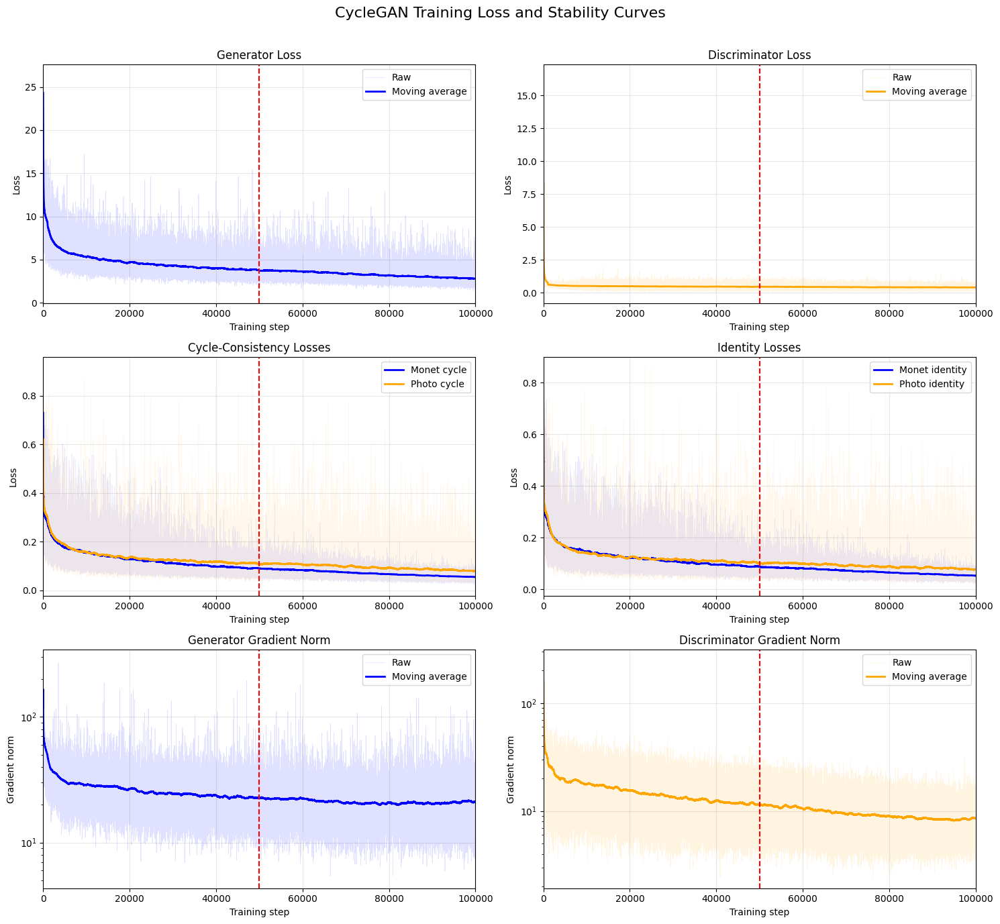

Saved improved curves: /app/task3_cyclegan_run3_diffaug_ema/outputs/figures/loss_and_stability_curves_smoothed.png


In [17]:
# Read the saved training values
history_df = pd.read_csv(PROJECT_DIR / "training_history.csv")

# Number of steps used for the moving average
SMOOTH_WINDOW = 1000

# Calculate smoother versions of every curve
history_df["loss_G_smooth"] = history_df["loss_G"].rolling(
    window=SMOOTH_WINDOW, min_periods=1
).mean()

history_df["loss_D_smooth"] = history_df["loss_D"].rolling(
    window=SMOOTH_WINDOW, min_periods=1
).mean()

history_df["cycle_A_smooth"] = history_df["cycle_A"].rolling(
    window=SMOOTH_WINDOW, min_periods=1
).mean()

history_df["cycle_B_smooth"] = history_df["cycle_B"].rolling(
    window=SMOOTH_WINDOW, min_periods=1
).mean()

history_df["identity_A_smooth"] = history_df["identity_A"].rolling(
    window=SMOOTH_WINDOW, min_periods=1
).mean()

history_df["identity_B_smooth"] = history_df["identity_B"].rolling(
    window=SMOOTH_WINDOW, min_periods=1
).mean()

history_df["grad_norm_G_smooth"] = history_df["grad_norm_G"].rolling(
    window=SMOOTH_WINDOW, min_periods=1
).mean()

history_df["grad_norm_D_smooth"] = history_df["grad_norm_D"].rolling(
    window=SMOOTH_WINDOW, min_periods=1
).mean()


# Create six separate plots
fig, axes = plt.subplots(3, 2, figsize=(15, 14))


# ---------------------------------------------------------
# 1. Generator loss
# ---------------------------------------------------------
axes[0, 0].plot(
    history_df["step"],
    history_df["loss_G"],
    color="blue",
    alpha=0.12,
    linewidth=0.5,
    label="Raw"
)

axes[0, 0].plot(
    history_df["step"],
    history_df["loss_G_smooth"],
    color="blue",
    linewidth=2,
    label="Moving average"
)

axes[0, 0].set_title("Generator Loss")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()


# ---------------------------------------------------------
# 2. Discriminator loss
# ---------------------------------------------------------
axes[0, 1].plot(
    history_df["step"],
    history_df["loss_D"],
    color="orange",
    alpha=0.12,
    linewidth=0.5,
    label="Raw"
)

axes[0, 1].plot(
    history_df["step"],
    history_df["loss_D_smooth"],
    color="orange",
    linewidth=2,
    label="Moving average"
)

axes[0, 1].set_title("Discriminator Loss")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()


# ---------------------------------------------------------
# 3. Cycle-consistency losses
# ---------------------------------------------------------
axes[1, 0].plot(
    history_df["step"],
    history_df["cycle_A"],
    color="blue",
    alpha=0.08,
    linewidth=0.5
)

axes[1, 0].plot(
    history_df["step"],
    history_df["cycle_B"],
    color="orange",
    alpha=0.08,
    linewidth=0.5
)

axes[1, 0].plot(
    history_df["step"],
    history_df["cycle_A_smooth"],
    color="blue",
    linewidth=2,
    label="Monet cycle"
)

axes[1, 0].plot(
    history_df["step"],
    history_df["cycle_B_smooth"],
    color="orange",
    linewidth=2,
    label="Photo cycle"
)

axes[1, 0].set_title("Cycle-Consistency Losses")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()


# ---------------------------------------------------------
# 4. Identity losses
# ---------------------------------------------------------
axes[1, 1].plot(
    history_df["step"],
    history_df["identity_A"],
    color="blue",
    alpha=0.08,
    linewidth=0.5
)

axes[1, 1].plot(
    history_df["step"],
    history_df["identity_B"],
    color="orange",
    alpha=0.08,
    linewidth=0.5
)

axes[1, 1].plot(
    history_df["step"],
    history_df["identity_A_smooth"],
    color="blue",
    linewidth=2,
    label="Monet identity"
)

axes[1, 1].plot(
    history_df["step"],
    history_df["identity_B_smooth"],
    color="orange",
    linewidth=2,
    label="Photo identity"
)

axes[1, 1].set_title("Identity Losses")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].legend()


# ---------------------------------------------------------
# 5. Generator gradient norm
# ---------------------------------------------------------
axes[2, 0].plot(
    history_df["step"],
    history_df["grad_norm_G"],
    color="blue",
    alpha=0.12,
    linewidth=0.5,
    label="Raw"
)

axes[2, 0].plot(
    history_df["step"],
    history_df["grad_norm_G_smooth"],
    color="blue",
    linewidth=2,
    label="Moving average"
)

axes[2, 0].set_title("Generator Gradient Norm")
axes[2, 0].set_ylabel("Gradient norm")
axes[2, 0].set_yscale("log")
axes[2, 0].legend()


# ---------------------------------------------------------
# 6. Discriminator gradient norm
# ---------------------------------------------------------
axes[2, 1].plot(
    history_df["step"],
    history_df["grad_norm_D"],
    color="orange",
    alpha=0.12,
    linewidth=0.5,
    label="Raw"
)

axes[2, 1].plot(
    history_df["step"],
    history_df["grad_norm_D_smooth"],
    color="orange",
    linewidth=2,
    label="Moving average"
)

axes[2, 1].set_title("Discriminator Gradient Norm")
axes[2, 1].set_ylabel("Gradient norm")
axes[2, 1].set_yscale("log")
axes[2, 1].legend()


# Add common settings to every plot
for axis in axes.flat:
    axis.set_xlabel("Training step")
    axis.grid(alpha=0.3)

    # Mark where learning-rate decay started
    axis.axvline(
        x=50000,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="LR decay starts"
    )

    axis.set_xlim(0, 100000)


# Main title for the complete figure
fig.suptitle(
    "CycleGAN Training Loss and Stability Curves",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

# Save this as a new file so the original plot is preserved
loss_curve_path = FIGURE_DIR / "loss_and_stability_curves_smoothed.png"

plt.savefig(
    loss_curve_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved improved curves:", loss_curve_path)

## 13. Generate translated images in both directions

The output filenames keep the original image stem. Evaluation mode is deterministic and does not use random cropping or flipping.

In [18]:
def load_eval_tensor(path):
    image = Image.open(path).convert("RGB")
    return eval_transform(image).unsqueeze(0).to(DEVICE)


def save_tensor_as_jpeg(tensor, output_path):
    image = tensor.detach().cpu().squeeze(0)
    image = (image * 0.5 + 0.5).clamp(0, 1)
    array = (image.permute(1, 2, 0).numpy() * 255).round().astype(np.uint8)
    Image.fromarray(array).save(output_path, format="JPEG", quality=95)


def fixed_sample(paths, maximum_count):
    paths = list(paths)
    random_generator = random.Random(SEED)
    random_generator.shuffle(paths)
    return paths[: min(maximum_count, len(paths))]


@torch.no_grad()
def generate_translations(input_paths, model, output_folder, maximum_count):
    output_folder.mkdir(parents=True, exist_ok=True)
    selected_paths = fixed_sample(input_paths, maximum_count)

    model.eval()
    records = []

    for path in tqdm(selected_paths, desc=f"Generating {output_folder.name}"):
        input_tensor = load_eval_tensor(path)
        output_tensor = model(input_tensor)
        output_path = output_folder / f"{path.stem}.jpg"
        save_tensor_as_jpeg(output_tensor, output_path)
        records.append({"input_path": str(path), "output_path": str(output_path)})

    return pd.DataFrame(records)


monet_to_photo_df = generate_translations(
    monet_paths,
    G_A2B,
    PRED_A2B_DIR,
    EVAL_IMAGES,
)

photo_to_monet_df = generate_translations(
    photo_paths,
    G_B2A,
    PRED_B2A_DIR,
    EVAL_IMAGES,
)

monet_to_photo_df.to_csv(OUTPUT_DIR / "monet_to_photo_files.csv", index=False)
photo_to_monet_df.to_csv(OUTPUT_DIR / "photo_to_monet_files.csv", index=False)

print("Monet to Photo images:", len(monet_to_photo_df))
print("Photo to Monet images:", len(photo_to_monet_df))

Generating pred_B2A_photo_to_monet: 100%|██████████| 300/300 [00:07<00:00, 37.51it/s]

Monet to Photo images: 300
Photo to Monet images: 300


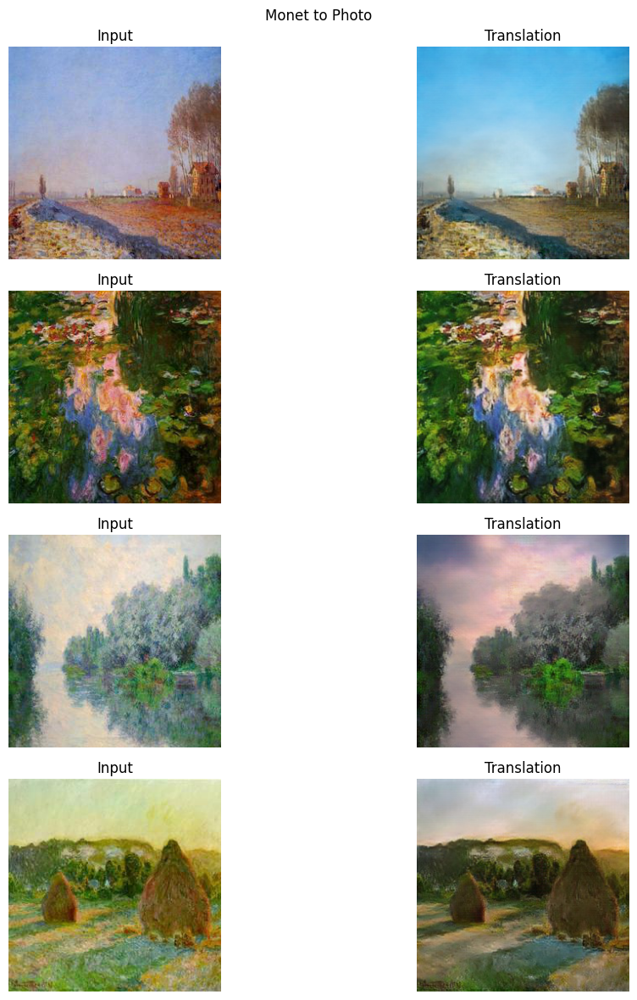

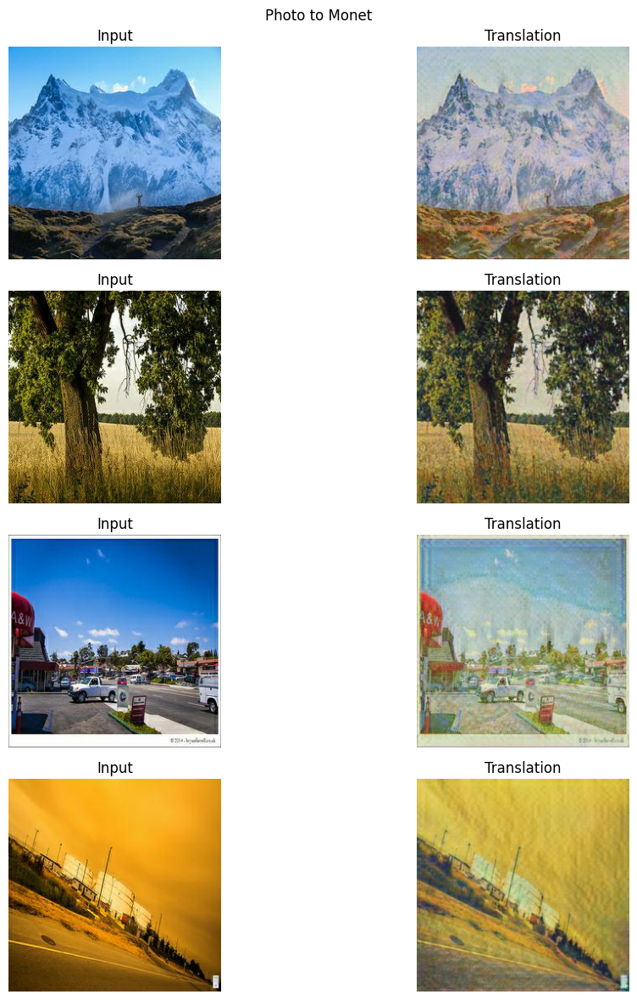

In [19]:
def show_translation_results(records, title, count=4):
    count = min(count, len(records))
    selected = records.iloc[:count]

    plt.figure(figsize=(12, count * 3))

    for row_number, (_, row) in enumerate(selected.iterrows()):
        input_image = Image.open(row["input_path"]).convert("RGB")
        output_image = Image.open(row["output_path"]).convert("RGB")

        plt.subplot(count, 2, row_number * 2 + 1)
        plt.imshow(input_image)
        plt.axis("off")
        plt.title("Input")

        plt.subplot(count, 2, row_number * 2 + 2)
        plt.imshow(output_image)
        plt.axis("off")
        plt.title("Translation")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_translation_results(monet_to_photo_df, "Monet to Photo")
show_translation_results(photo_to_monet_df, "Photo to Monet")

## 14. Feature-based metrics: FID, KID, precision, recall, and content similarity

The pretrained Inception network is used only as an evaluation feature extractor after the images have been created. It is not part of CycleGAN training and is not used to modify Kaggle outputs.

Lower FID and KID are better. Higher precision, recall, and cosine similarity are better.

In [20]:
feature_model = inception_v3(weights=Inception_V3_Weights.DEFAULT)
feature_model.fc = nn.Identity()
feature_model.eval().to(DEVICE)

imagenet_mean = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
imagenet_std = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)


@torch.no_grad()
def extract_inception_features(paths, batch_size=16):
    all_features = []

    for start in tqdm(range(0, len(paths), batch_size), desc="Extracting features"):
        batch_paths = paths[start : start + batch_size]
        images = []

        for path in batch_paths:
            image = Image.open(path).convert("RGB")
            image = transforms.ToTensor()(image)
            images.append(image)

        batch = torch.stack(images).to(DEVICE)
        batch = F.interpolate(batch, size=(299, 299), mode="bilinear", align_corners=False)
        batch = (batch - imagenet_mean) / imagenet_std

        features = feature_model(batch)
        all_features.append(features.cpu())

    return torch.cat(all_features, dim=0).numpy()


def calculate_fid(real_features, fake_features):
    real_mean = np.mean(real_features, axis=0)
    fake_mean = np.mean(fake_features, axis=0)

    real_covariance = np.cov(real_features, rowvar=False)
    fake_covariance = np.cov(fake_features, rowvar=False)

    mean_difference = real_mean - fake_mean
    covariance_mean, _ = linalg.sqrtm(real_covariance @ fake_covariance, disp=False)

    if np.iscomplexobj(covariance_mean):
        covariance_mean = covariance_mean.real

    fid = (
        mean_difference @ mean_difference
        + np.trace(real_covariance)
        + np.trace(fake_covariance)
        - 2 * np.trace(covariance_mean)
    )
    return float(fid)


def polynomial_kernel(x, y):
    feature_count = x.shape[1]
    return (x @ y.T / feature_count + 1.0) ** 3


def calculate_kid(real_features, fake_features, subset_size=100, repeats=20):
    subset_size = min(subset_size, len(real_features), len(fake_features))
    if subset_size < 2:
        return float("nan")

    random_generator = np.random.default_rng(SEED)
    scores = []

    for _ in range(repeats):
        real_subset = real_features[random_generator.choice(len(real_features), subset_size, replace=False)]
        fake_subset = fake_features[random_generator.choice(len(fake_features), subset_size, replace=False)]

        kernel_real = polynomial_kernel(real_subset, real_subset)
        kernel_fake = polynomial_kernel(fake_subset, fake_subset)
        kernel_cross = polynomial_kernel(real_subset, fake_subset)

        real_term = (kernel_real.sum() - np.trace(kernel_real)) / (subset_size * (subset_size - 1))
        fake_term = (kernel_fake.sum() - np.trace(kernel_fake)) / (subset_size * (subset_size - 1))
        cross_term = kernel_cross.mean()

        scores.append(real_term + fake_term - 2 * cross_term)

    return float(np.mean(scores))


def calculate_precision_recall(real_features, fake_features, neighbors=3):
    real_tensor = torch.tensor(real_features, dtype=torch.float32)
    fake_tensor = torch.tensor(fake_features, dtype=torch.float32)

    real_to_real = torch.cdist(real_tensor, real_tensor)
    fake_to_fake = torch.cdist(fake_tensor, fake_tensor)
    fake_to_real = torch.cdist(fake_tensor, real_tensor)

    real_radius = real_to_real.topk(neighbors + 1, largest=False).values[:, -1]
    fake_radius = fake_to_fake.topk(neighbors + 1, largest=False).values[:, -1]

    precision = (fake_to_real <= real_radius.unsqueeze(0)).any(dim=1).float().mean()
    recall = (fake_to_real <= fake_radius.unsqueeze(1)).any(dim=0).float().mean()

    return float(precision.item()), float(recall.item())


def calculate_matching_cosine(input_features, translated_features):
    count = min(len(input_features), len(translated_features))
    input_tensor = torch.tensor(input_features[:count], dtype=torch.float32)
    translated_tensor = torch.tensor(translated_features[:count], dtype=torch.float32)
    scores = F.cosine_similarity(input_tensor, translated_tensor, dim=1)
    return float(scores.mean().item())

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:07<00:00, 14.6MB/s] 


In [21]:
# Use the same fixed number from each domain for a fair comparison.
real_monet_metric_paths = fixed_sample(monet_paths, EVAL_IMAGES)
real_photo_metric_paths = fixed_sample(photo_paths, EVAL_IMAGES)

fake_monet_paths = [Path(path) for path in photo_to_monet_df["output_path"].tolist()]
fake_photo_paths = [Path(path) for path in monet_to_photo_df["output_path"].tolist()]

input_photo_paths = [Path(path) for path in photo_to_monet_df["input_path"].tolist()]
input_monet_paths = [Path(path) for path in monet_to_photo_df["input_path"].tolist()]

real_monet_features = extract_inception_features(real_monet_metric_paths)
real_photo_features = extract_inception_features(real_photo_metric_paths)
fake_monet_features = extract_inception_features(fake_monet_paths)
fake_photo_features = extract_inception_features(fake_photo_paths)
input_photo_features = extract_inception_features(input_photo_paths)
input_monet_features = extract_inception_features(input_monet_paths)

fid_photo_to_monet = calculate_fid(real_monet_features, fake_monet_features)
fid_monet_to_photo = calculate_fid(real_photo_features, fake_photo_features)

kid_photo_to_monet = calculate_kid(real_monet_features, fake_monet_features)
kid_monet_to_photo = calculate_kid(real_photo_features, fake_photo_features)

precision_photo_to_monet, recall_photo_to_monet = calculate_precision_recall(
    real_monet_features, fake_monet_features
)
precision_monet_to_photo, recall_monet_to_photo = calculate_precision_recall(
    real_photo_features, fake_photo_features
)

content_cosine_photo_to_monet = calculate_matching_cosine(input_photo_features, fake_monet_features)
content_cosine_monet_to_photo = calculate_matching_cosine(input_monet_features, fake_photo_features)

print("Photo -> Monet FID:", fid_photo_to_monet)
print("Monet -> Photo FID:", fid_monet_to_photo)
print("Photo -> Monet KID:", kid_photo_to_monet)
print("Monet -> Photo KID:", kid_monet_to_photo)
print("Photo -> Monet precision / recall:", precision_photo_to_monet, recall_photo_to_monet)
print("Monet -> Photo precision / recall:", precision_monet_to_photo, recall_monet_to_photo)
print("Photo -> Monet content cosine:", content_cosine_photo_to_monet)
print("Monet -> Photo content cosine:", content_cosine_monet_to_photo)

Extracting features: 100%|██████████| 19/19 [00:03<00:00,  5.42it/s]


Photo -> Monet FID: 104.640693091478
Monet -> Photo FID: 104.79692643781141
Photo -> Monet KID: 0.010973721287467274
Monet -> Photo KID: 0.019733526306922978
Photo -> Monet precision / recall: 0.3933333456516266 0.6066666841506958
Monet -> Photo precision / recall: 0.6800000071525574 0.3233333230018616
Photo -> Monet content cosine: 0.8064574599266052
Monet -> Photo content cosine: 0.8604134917259216


## 15. Cycle-reconstruction L1 and LPIPS

These metrics compare each original image with its cycle reconstruction:

- Monet → Photo → Monet
- Photo → Monet → Photo

Lower L1 and LPIPS are better.

In [22]:
import lpips

lpips_model = lpips.LPIPS(net="alex").to(DEVICE).eval()


@torch.no_grad()
def calculate_cycle_metrics(paths, first_generator, second_generator):
    l1_scores = []
    lpips_scores = []

    first_generator.eval()
    second_generator.eval()

    for path in tqdm(paths, desc="Cycle metrics"):
        original = load_eval_tensor(path)
        translated = first_generator(original)
        reconstructed = second_generator(translated)

        l1_scores.append(F.l1_loss(reconstructed, original).item())
        lpips_scores.append(lpips_model(reconstructed, original).mean().item())

    return float(np.mean(l1_scores)), float(np.mean(lpips_scores))


cycle_l1_monet, cycle_lpips_monet = calculate_cycle_metrics(
    real_monet_metric_paths,
    G_A2B,
    G_B2A,
)

cycle_l1_photo, cycle_lpips_photo = calculate_cycle_metrics(
    real_photo_metric_paths,
    G_B2A,
    G_A2B,
)

print("Monet cycle L1:", cycle_l1_monet)
print("Photo cycle L1:", cycle_l1_photo)
print("Monet cycle LPIPS:", cycle_lpips_monet)
print("Photo cycle LPIPS:", cycle_lpips_photo)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:16<00:00, 14.5MB/s] 


Loading model from: /opt/conda/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


Cycle metrics: 100%|██████████| 300/300 [00:05<00:00, 59.59it/s]

Monet cycle L1: 0.06653571754073104
Photo cycle L1: 0.08544429187352459
Monet cycle LPIPS: 0.20020580346385639
Photo cycle LPIPS: 0.1793797777965665


## 16. Create the blinded 30-image human-audit set

This cell creates 30 fixed Photo → Monet examples and a CSV template. Two raters should independently score every sample from 1 to 5 for:

- Style quality
- Content preservation
- Artifacts, where 5 means no visible artifacts

Do not show model settings or cherry-pick examples. Both raters must use the same 30 fixed samples.

In [23]:
@torch.no_grad()
def create_human_audit_set(number_of_samples=30):
    selected_paths = fixed_sample(photo_paths, number_of_samples)
    rows = []

    G_B2A.eval()

    for index, input_path in enumerate(selected_paths, start=1):
        input_image = Image.open(input_path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
        input_tensor = load_eval_tensor(input_path)
        translated_tensor = G_B2A(input_tensor)

        translated = translated_tensor.detach().cpu().squeeze(0)
        translated = (translated * 0.5 + 0.5).clamp(0, 1)
        translated_array = (translated.permute(1, 2, 0).numpy() * 255).round().astype(np.uint8)
        translated_image = Image.fromarray(translated_array)

        panel = Image.new("RGB", (IMAGE_SIZE * 2, IMAGE_SIZE), color="white")
        panel.paste(input_image, (0, 0))
        panel.paste(translated_image, (IMAGE_SIZE, 0))

        sample_name = f"sample_{index:03d}.jpg"
        panel.save(AUDIT_DIR / sample_name, quality=95)

        rows.append({
            "sample_id": index,
            "audit_image": sample_name,
            "rater1_style": np.nan,
            "rater1_content": np.nan,
            "rater1_artifacts": np.nan,
            "rater2_style": np.nan,
            "rater2_content": np.nan,
            "rater2_artifacts": np.nan,
        })

    audit_csv = AUDIT_DIR / "human_audit_ratings.csv"
    pd.DataFrame(rows).to_csv(audit_csv, index=False)

    print("Human-audit images:", AUDIT_DIR)
    print("Rating template:", audit_csv)


create_human_audit_set(30)

Human-audit images: /app/task3_cyclegan_run3_diffaug_ema/outputs/human_audit
Rating template: /app/task3_cyclegan_run3_diffaug_ema/outputs/human_audit/human_audit_ratings.csv


## 17. Calculate the human-audit score and agreement

Run this cell only after both raters fill all rating columns in `human_audit_ratings.csv`.

In [24]:
from sklearn.metrics import cohen_kappa_score

audit_csv = AUDIT_DIR / "human_audit_ratings.csv"
audit_df = pd.read_csv(audit_csv)

rating_columns = [
    "rater1_style", "rater1_content", "rater1_artifacts",
    "rater2_style", "rater2_content", "rater2_artifacts",
]

human_audit_score = float("nan")
human_kappa = float("nan")
human_percent_agreement = float("nan")

if audit_df[rating_columns].notna().all().all():
    kappa_scores = []
    agreement_scores = []

    for category in ["style", "content", "artifacts"]:
        rater1 = audit_df[f"rater1_{category}"].astype(int)
        rater2 = audit_df[f"rater2_{category}"].astype(int)

        kappa_scores.append(cohen_kappa_score(rater1, rater2, weights="quadratic"))
        agreement_scores.append((rater1 == rater2).mean())

    human_audit_score = float(audit_df[rating_columns].to_numpy().mean())
    human_kappa = float(np.mean(kappa_scores))
    human_percent_agreement = float(np.mean(agreement_scores) * 100)

    print("Human audit mean score:", human_audit_score)
    print("Mean weighted Cohen's kappa:", human_kappa)
    print("Exact percent agreement:", human_percent_agreement)
else:
    print("Human ratings are not complete yet. Fill the CSV and run this cell again.")

Human ratings are not complete yet. Fill the CSV and run this cell again.


## 18. Generate the complete Photo → Monet Kaggle output

Set `GENERATE_KAGGLE_PACKAGE = True` only after loading the final trained checkpoint. This generates one output for every photo without manual selection or editing.

The cell creates:

- `submission_images.zip`: all generated JPEG files
- `submission.csv`: a filename manifest

Check the private competition's exact submission page. If it provides a `sample_submission.csv`, its required columns take priority over the simple manifest created here.

In [25]:
GENERATE_KAGGLE_PACKAGE = True

if GENERATE_KAGGLE_PACKAGE:
    # Clear only generated JPEG files from an earlier package.
    for old_image in KAGGLE_IMAGE_DIR.glob("*.jpg"):
        old_image.unlink()

    all_kaggle_records = generate_translations(
        photo_paths,
        G_B2A,
        KAGGLE_IMAGE_DIR,
        maximum_count=len(photo_paths),
    )

    submission_csv_path = PROJECT_DIR / "submission.csv"
    submission_df = pd.DataFrame({
        "image_id": [Path(path).stem for path in all_kaggle_records["input_path"]],
        "generated_file": [Path(path).name for path in all_kaggle_records["output_path"]],
    })
    submission_df.to_csv(submission_csv_path, index=False)

    submission_zip_path = PROJECT_DIR / "submission_images.zip"
    with zipfile.ZipFile(submission_zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zip_file:
        for image_path in sorted(KAGGLE_IMAGE_DIR.glob("*.jpg")):
            zip_file.write(image_path, arcname=image_path.name)

    print("Kaggle images generated:", len(all_kaggle_records))
    print("Submission manifest:", submission_csv_path)
    print("Submission image ZIP:", submission_zip_path)
else:
    print("Kaggle package skipped. Set GENERATE_KAGGLE_PACKAGE = True for the final model.")

Generating kaggle_photo_to_monet: 100%|██████████| 7038/7038 [03:02<00:00, 38.58it/s]


Kaggle images generated: 7038
Submission manifest: /app/task3_cyclegan_run3_diffaug_ema/submission.csv
Submission image ZIP: /app/task3_cyclegan_run3_diffaug_ema/submission_images.zip


## 19. Save the complete metrics report

Enter the Kaggle results after submission. Human-audit values remain blank until two raters complete the audit CSV and its calculation cell is rerun.

In [26]:
KAGGLE_PUBLIC_SCORE = np.nan
KAGGLE_PRIVATE_SCORE = np.nan
KAGGLE_RANK = np.nan

recent_history = history_df.tail(min(100, len(history_df)))

metrics_rows = [
    {"metric": "FID", "direction": "Photo_to_Monet", "value": fid_photo_to_monet, "better": "lower"},
    {"metric": "FID", "direction": "Monet_to_Photo", "value": fid_monet_to_photo, "better": "lower"},
    {"metric": "KID", "direction": "Photo_to_Monet", "value": kid_photo_to_monet, "better": "lower"},
    {"metric": "KID", "direction": "Monet_to_Photo", "value": kid_monet_to_photo, "better": "lower"},
    {"metric": "Generative precision", "direction": "Photo_to_Monet", "value": precision_photo_to_monet, "better": "higher"},
    {"metric": "Generative recall", "direction": "Photo_to_Monet", "value": recall_photo_to_monet, "better": "higher"},
    {"metric": "Generative precision", "direction": "Monet_to_Photo", "value": precision_monet_to_photo, "better": "higher"},
    {"metric": "Generative recall", "direction": "Monet_to_Photo", "value": recall_monet_to_photo, "better": "higher"},
    {"metric": "Cycle reconstruction L1", "direction": "Monet_cycle", "value": cycle_l1_monet, "better": "lower"},
    {"metric": "Cycle reconstruction L1", "direction": "Photo_cycle", "value": cycle_l1_photo, "better": "lower"},
    {"metric": "LPIPS", "direction": "Monet_cycle", "value": cycle_lpips_monet, "better": "lower"},
    {"metric": "LPIPS", "direction": "Photo_cycle", "value": cycle_lpips_photo, "better": "lower"},
    {"metric": "Content cosine similarity", "direction": "Photo_to_Monet", "value": content_cosine_photo_to_monet, "better": "higher"},
    {"metric": "Content cosine similarity", "direction": "Monet_to_Photo", "value": content_cosine_monet_to_photo, "better": "higher"},
    {"metric": "Final cycle loss", "direction": "Monet_cycle", "value": recent_history["cycle_A"].mean(), "better": "lower"},
    {"metric": "Final cycle loss", "direction": "Photo_cycle", "value": recent_history["cycle_B"].mean(), "better": "lower"},
    {"metric": "Final identity loss", "direction": "Monet", "value": recent_history["identity_A"].mean(), "better": "lower"},
    {"metric": "Final identity loss", "direction": "Photo", "value": recent_history["identity_B"].mean(), "better": "lower"},
    {"metric": "Mean generator gradient norm", "direction": "Both", "value": recent_history["grad_norm_G"].mean(), "better": "stable"},
    {"metric": "Mean discriminator gradient norm", "direction": "Both", "value": recent_history["grad_norm_D"].mean(), "better": "stable"},
    {"metric": "NaN count", "direction": "Training", "value": nan_count, "better": "lower"},
    {"metric": "Total parameters", "direction": "All networks", "value": sum(parameter_counts.values()), "better": "reported"},
    {"metric": "Training time hours", "direction": "Training", "value": training_hours, "better": "reported"},
    {"metric": "Images per second", "direction": "Training", "value": images_per_second, "better": "higher"},
    {"metric": "Peak allocated GPU memory GB", "direction": "Training", "value": peak_memory_gb, "better": "lower"},
    {"metric": "Human audit mean score", "direction": "Photo_to_Monet", "value": human_audit_score, "better": "higher"},
    {"metric": "Human audit weighted kappa", "direction": "Photo_to_Monet", "value": human_kappa, "better": "higher"},
    {"metric": "Human audit exact agreement percent", "direction": "Photo_to_Monet", "value": human_percent_agreement, "better": "higher"},
    {"metric": "Kaggle public score", "direction": "Photo_to_Monet", "value": KAGGLE_PUBLIC_SCORE, "better": "competition"},
    {"metric": "Kaggle private score", "direction": "Photo_to_Monet", "value": KAGGLE_PRIVATE_SCORE, "better": "competition"},
    {"metric": "Kaggle rank", "direction": "Photo_to_Monet", "value": KAGGLE_RANK, "better": "lower"},
]

metrics_df = pd.DataFrame(metrics_rows)
metrics_csv_path = PROJECT_DIR / "full_metrics_report.csv"
metrics_md_path = PROJECT_DIR / "METRICS.md"

metrics_df.to_csv(metrics_csv_path, index=False)

with open(metrics_md_path, "w", encoding="utf-8") as file:
    file.write("# Task 3 CycleGAN Metrics\n\n")
    file.write(f"- Run mode: {RUN_MODE}\n")
    file.write(f"- Seed: {SEED}\n")
    file.write(f"- GPU: {torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'CPU'}\n")
    file.write(f"- Training steps: {MAX_STEPS}\n")
    file.write(f"- Evaluation images per domain: {EVAL_IMAGES}\n\n")
    file.write(metrics_df.to_markdown(index=False))
    file.write("\n")

print(metrics_df.to_string(index=False))
print("Metrics CSV:", metrics_csv_path)
print("Metrics Markdown:", metrics_md_path)

                             metric      direction        value      better
                                FID Photo_to_Monet 1.046407e+02       lower
                                FID Monet_to_Photo 1.047969e+02       lower
                                KID Photo_to_Monet 1.097372e-02       lower
                                KID Monet_to_Photo 1.973353e-02       lower
               Generative precision Photo_to_Monet 3.933333e-01      higher
                  Generative recall Photo_to_Monet 6.066667e-01      higher
               Generative precision Monet_to_Photo 6.800000e-01      higher
                  Generative recall Monet_to_Photo 3.233333e-01      higher
            Cycle reconstruction L1    Monet_cycle 6.653572e-02       lower
            Cycle reconstruction L1    Photo_cycle 8.544429e-02       lower
                              LPIPS    Monet_cycle 2.002058e-01       lower
                              LPIPS    Photo_cycle 1.793798e-01       lower
          Co

## 20. Save run settings and copy the final log

This creates a small manifest connecting the run settings, checkpoint, and reported metrics.

In [27]:
run_manifest = {
    "student": "Omkar Rajale",
    "SID4": "0298",
    "SEED": SEED,
    "SLICE": 298,
    "HP_ID": 4,
    "CLS_A": 8,
    "CLS_B": 1,
    "run_mode": RUN_MODE,
    "dataset": {
        "monet_folder": str(MONET_DIR),
        "photo_folder": str(PHOTO_DIR),
        "monet_images": len(monet_paths),
        "photo_images": len(photo_paths),
    },
    "model": "CycleGAN with two 9-block ResNet generators (ConvTranspose2d upsampling) and two PatchGAN discriminators, DiffAugment on discriminator inputs, EMA generators",
    "diffaug_policy": DIFFAUG_POLICY if USE_DIFFAUG else None,
    "ema_decay": EMA_DECAY if USE_EMA else None,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "max_steps": MAX_STEPS,
    "learning_rate": LEARNING_RATE,
    "lambda_cycle": LAMBDA_CYCLE,
    "lambda_identity": LAMBDA_IDENTITY,
    "mixed_precision": USE_AMP,
    "gpu": torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU",
    "pytorch_version": torch.__version__,
    "cuda_version": torch.version.cuda,
    "latest_checkpoint": str(CHECKPOINT_DIR / "cyclegan_latest.pt"),
    "metrics_file": str(PROJECT_DIR / "full_metrics_report.csv"),
}

manifest_path = PROJECT_DIR / "run_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as file:
    json.dump(run_manifest, file, indent=2)

sys.stdout.flush()
sys.stderr.flush()

if RUN_LOG_PATH.exists() and RUN_LOG_PATH.resolve() != FINAL_RUN_LOG_PATH.resolve():
    shutil.copy2(RUN_LOG_PATH, FINAL_RUN_LOG_PATH)

print("Manifest:", manifest_path)
print("Run log:", FINAL_RUN_LOG_PATH)
print("Latest checkpoint:", CHECKPOINT_DIR / "cyclegan_latest.pt")
print("Task 3 notebook run is complete.")

Manifest: /app/task3_cyclegan_run3_diffaug_ema/run_manifest.json
Run log: /app/task3_cyclegan_run3_diffaug_ema/RUN_LOG.txt
Latest checkpoint: /app/task3_cyclegan_run3_diffaug_ema/checkpoints/cyclegan_latest.pt
Task 3 notebook run is complete.


## Before final submission

After the full run:

1. Make sure the notebook is saved with all outputs intact.
2. Confirm `RUN_LOG.txt`, `METRICS.md`, `full_metrics_report.csv`, checkpoints, figures, and generated images exist.
3. Complete the two-rater audit and rerun Sections 17 and 19.
4. Generate the complete Kaggle package, submit it, enter the scores/rank, and rerun Section 19.
5. Write `results.md` and `failure_analysis.md` using the actual outputs from this run.
6. Add `AI_USE.md` in your own words according to the course questions.
7. Do not commit `kaggle.json`, personal paths, or credentials.